# Risk Parity from Scratch

**pyportfolios.com tutorial T07** · SPY · TLT · GLD · DBC, Jan 2010 – Dec 2024 · SciPy (build) · Riskfolio-Lib (validate)

A 25%-each portfolio is only diversified in *dollars* — measured in risk, equities
dominate it. Risk parity allocates by **risk contribution** instead of capital:
every asset contributes the same share of portfolio variance. In this notebook we

1. define risk contributions and show how badly equal capital weights concentrate risk,
2. solve the equal-risk-contribution (ERC) weights with `scipy.optimize.minimize`,
3. validate the solution against Riskfolio-Lib's risk-parity optimizer, and
4. backtest monthly-rebalanced risk parity vs 60/40 and equal weight, 2010–2024.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

plt.rcParams["figure.figsize"] = (10, 5)
ASSETS = ["SPY", "TLT", "GLD", "DBC"]

## 1 · Data: four asset classes

Equities (SPY), long Treasuries (TLT), gold (GLD) and broad commodities (DBC) —
the classic all-weather building blocks. Fifteen years of adjusted closes covering
the post-GFC bull, the 2013 taper tantrum, COVID, and the 2022 bond crash.

In [2]:
px = yf.download(ASSETS, start="2010-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"][ASSETS].dropna()
rets = px.pct_change().dropna()

cov = rets.cov().values * 252            # annualised covariance
vols = np.sqrt(np.diag(cov))
for a, v in zip(ASSETS, vols):
    print(f"{a}: ann. vol = {v:.1%}")

SPY: ann. vol = 17.1%
TLT: ann. vol = 15.3%
GLD: ann. vol = 15.5%
DBC: ann. vol = 17.2%


## 2 · Risk contributions — where equal weights go wrong

Portfolio volatility decomposes exactly across assets. With $\sigma_p^2 = w'\Sigma w$,
the **risk contribution share** of asset $i$ is

$$RC_i = \frac{w_i\,(\Sigma w)_i}{w'\Sigma w}, \qquad \sum_i RC_i = 1.$$

Compute it for the naive 25%-each portfolio and the punchline writes itself: capital
is split evenly, risk is not.

SPY: RC = 25.7%
TLT: RC = 11.1%
GLD: RC = 29.8%
DBC: RC = 33.4%
SPY share of 60/40 risk: 83.1%


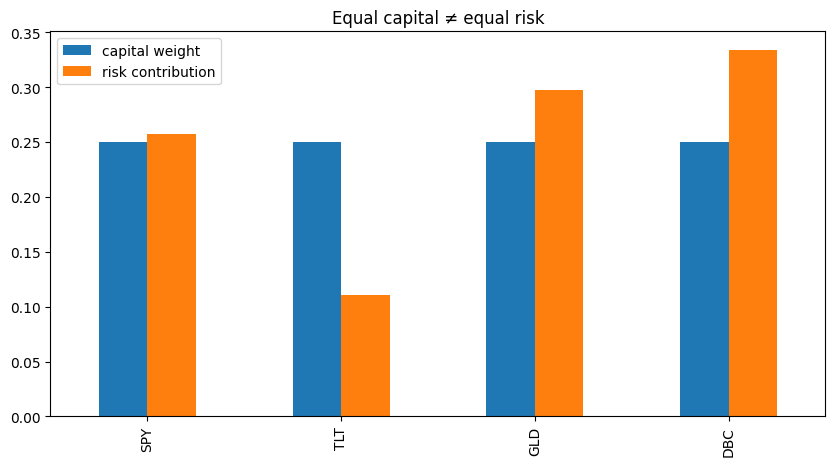

In [3]:
def risk_contrib(w, cov):
    return w * (cov @ w) / (w @ cov @ w)

w_eq = np.full(4, 0.25)
rc_eq = risk_contrib(w_eq, cov)

pd.DataFrame({"capital weight": w_eq, "risk contribution": rc_eq},
             index=ASSETS).plot.bar(title="Equal capital ≠ equal risk")
for a, rc in zip(ASSETS, rc_eq):
    print(f"{a}: RC = {rc:.1%}")

# and the classic hook: in a 60/40, equities are almost all of the risk
w_6040 = np.array([0.60, 0.40, 0.0, 0.0])
print(f"SPY share of 60/40 risk: {risk_contrib(w_6040, cov)[0]:.1%}")

## 3 · Solving for equal risk contributions (SciPy)

The ERC portfolio makes every $RC_i = 1/n$. There is no closed form for general
$\Sigma$, but the problem is a small smooth optimisation: minimise the sum of squared
deviations of risk contributions from $1/n$, long-only, fully invested — SLSQP eats it.

In [4]:
def solve_erc(cov):
    n = cov.shape[0]
    objective = lambda w: np.sum((risk_contrib(w, cov) - 1/n) ** 2)
    res = minimize(objective, np.full(n, 1/n), method="SLSQP",
                   bounds=[(0, 1)] * n,
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                   options={"maxiter": 1000, "ftol": 1e-16})
    assert res.success, res.message
    return res.x

w_erc = solve_erc(cov)
rc_erc = risk_contrib(w_erc, cov)
for a, w, rc in zip(ASSETS, w_erc, rc_erc):
    print(f"{a}: weight = {w:.1%}   RC = {rc:.1%}")

SPY: weight = 25.3%   RC = 25.0%
TLT: weight = 33.2%   RC = 25.0%
GLD: weight = 20.8%   RC = 25.0%
DBC: weight = 20.7%   RC = 25.0%


## 4 · Validation: Riskfolio-Lib

Never trust a hand-rolled optimizer without a second opinion. Riskfolio-Lib solves the
same ERC problem through a convex reformulation (Spinu 2013) with a proper conic solver —
if our SLSQP weights match to ~1e-3, both are right.

In [5]:
import riskfolio as rp

port = rp.Portfolio(returns=rets)
port.assets_stats(method_mu="hist", method_cov="hist")
w_rf = port.rp_optimization(model="Classic", rm="MV", rf=0, b=None, hist=True)
w_rf = w_rf.loc[ASSETS, "weights"].values

print("scipy    :", np.round(w_erc, 4))
print("riskfolio:", np.round(w_rf, 4))
print(f"max |diff| = {np.abs(w_erc - w_rf).max():.2e}")

scipy    : [0.253  0.3323 0.2078 0.2069]
riskfolio: [0.253  0.3323 0.2078 0.2069]
max |diff| = 4.30e-06


## 5 · Backtest: risk parity vs 60/40 vs equal weight

Three constant-mix portfolios, rebalanced back to target at every month-end,
2010–2024. (The ERC weights use the full-sample covariance — fine for illustrating
the *risk profile*; a production system re-estimates on a rolling window.)

Risk parity   ret= 44.87%  vol=8.35%  Sharpe=0.79  maxDD=-16.8%
60/40         ret= 49.64%  vol=9.90%  Sharpe=1.01  maxDD=-26.2%
Equal weight  ret= 44.89%  vol=8.78%  Sharpe=0.75  maxDD=-16.6%


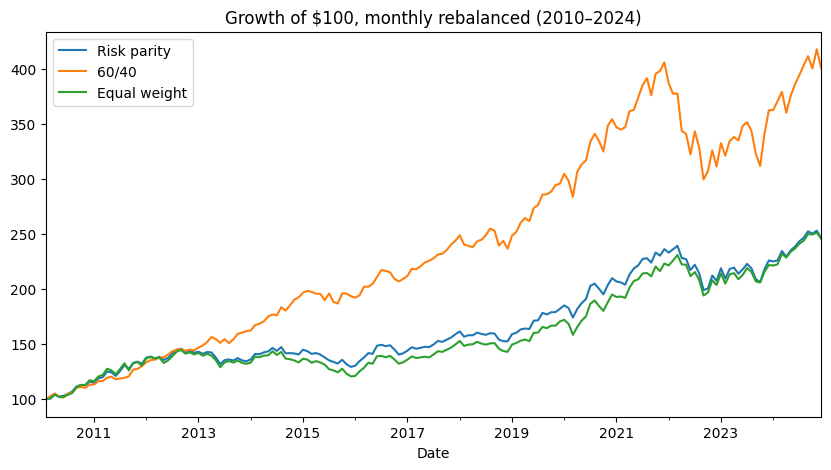

In [6]:
px_m = px.resample("ME").last()
rets_m = px_m.pct_change().dropna()

weights = {
    "Risk parity":  pd.Series(w_erc, index=ASSETS),
    "60/40":        pd.Series({"SPY": .6, "TLT": .4, "GLD": 0, "DBC": 0}),
    "Equal weight": pd.Series(0.25, index=ASSETS),
}
curves = {}
for name, w in weights.items():
    pr = rets_m.mul(w, axis=1).sum(axis=1)
    curves[name] = 100 * (1 + pr).cumprod()
    ann_ret = curves[name].iloc[-1] ** (12 / len(pr)) - 1
    ann_vol = pr.std(ddof=1) * np.sqrt(12)
    sharpe  = pr.mean() / pr.std(ddof=1) * np.sqrt(12)
    max_dd  = (curves[name] / curves[name].cummax() - 1).min()
    curves[name] /= curves[name].iloc[0] / 100
    print(f"{name:13s} ret={ann_ret: .2%}  vol={ann_vol:.2%}  "
          f"Sharpe={sharpe:.2f}  maxDD={max_dd: .1%}")

pd.DataFrame(curves).plot(title="Growth of $100, monthly rebalanced (2010–2024)");

## 6 · The leverage debate

Risk parity's Sharpe is competitive and its drawdowns are the shallowest of the three —
but unlevered it *returns less*, because equalising risk means holding a lot of
low-volatility bonds. The classic prescription (Bridgewater's All Weather, AQR) is to
lever the risk-parity portfolio up to equity-like volatility.

In [7]:
vol_rp   = rets_m.mul(weights["Risk parity"],  axis=1).sum(axis=1).std() * np.sqrt(12)
vol_6040 = rets_m.mul(weights["60/40"], axis=1).sum(axis=1).std() * np.sqrt(12)

lev = vol_6040 / vol_rp
print(f"leverage to run risk parity at 60/40 vol: {lev:.2f}x")
print(f"levered risk-parity return (rf=0 approx): "
      f"{lev * ((1 + rets_m.mul(weights['Risk parity'], axis=1).sum(axis=1)).prod() ** (12/len(rets_m)) - 1):.2%}")

leverage to run risk parity at 60/40 vol: 1.19x
levered risk-parity return (rf=0 approx): 7.58%


## Takeaways

- Equal capital weights are not diversification: 25% each puts most of the risk in equities.
- The ERC solution (SPY: 25.3%, TLT: 33.2%, GLD: 20.8%, DBC: 20.7%) equalises risk contributions at 25% each — heavy in bonds, light in equities and commodities.
- SciPy's SLSQP and Riskfolio-Lib's conic solver agree to ~1e-4 — always validate a hand-rolled optimizer.
- Unlevered risk parity earns less than 60/40 but with a better Sharpe and shallower drawdowns; the leverage
  required to match 60/40's volatility is the entire risk-parity debate in one number.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*